# Model Training and Evaluation
Logistic Regression, Random Forest, KNN

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV

from src.evaluation import get_metrics, plot_confusion_matrix, plot_roc

sns.set_theme(style='whitegrid')

In [2]:
X_train = pd.read_csv('../outputs/X_train.csv')
X_test  = pd.read_csv('../outputs/X_test.csv')
y_train = pd.read_csv('../outputs/y_train.csv').squeeze()
y_test  = pd.read_csv('../outputs/y_test.csv').squeeze()

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (5634, 26) | Test: (1409, 26)


## Logistic Regression

In [3]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

cv_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1')
print(f'CV F1: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')

lr.fit(X_train, y_train)

CV F1: 0.6410 ± 0.0205


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [4]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
metrics_lr = get_metrics(y_test, y_pred_lr, y_prob_lr)
print(metrics_lr)

{'Accuracy': 0.7437899219304471, 'Precision': 0.51138353765324, 'Recall': 0.7807486631016043, 'F1-Score': 0.617989417989418, 'MCC': 0.4597721845516137, 'ROC-AUC': 0.8488516882378776}


## Random Forest

In [5]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf_base, param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print('Best params:', rf_grid.best_params_)
rf = rf_grid.best_estimator_

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [6]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
metrics_rf = get_metrics(y_test, y_pred_rf, y_prob_rf)
print(metrics_rf)

{'Accuracy': 0.7743080198722498, 'Precision': 0.5566801619433198, 'Recall': 0.7352941176470589, 'F1-Score': 0.6336405529953917, 'MCC': 0.48463464550629737, 'ROC-AUC': 0.8510307680384406}


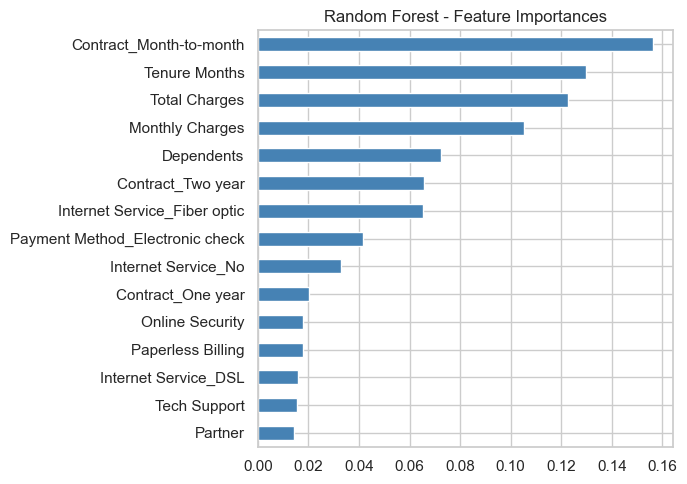

In [7]:
# feature importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 5))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title('Random Forest - Feature Importances')
plt.tight_layout()
plt.savefig('../outputs/figures/08_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## KNN

Best K: 19


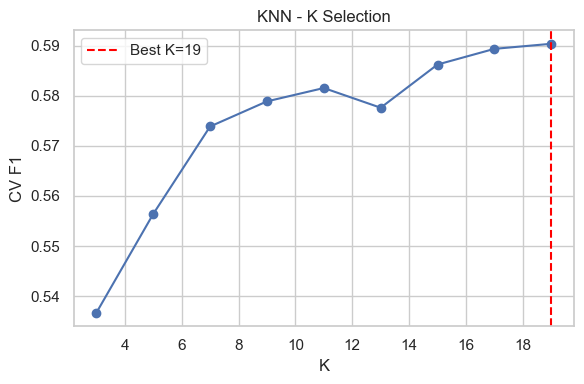

In [8]:
# try different k values to find the best one
k_values = range(3, 21, 2)
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    score = cross_val_score(knn, X_train, y_train, cv=5, scoring='f1').mean()
    f1_scores.append(score)

best_k = list(k_values)[np.argmax(f1_scores)]
print('Best K:', best_k)

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), f1_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K')
plt.ylabel('CV F1')
plt.title('KNN - K Selection')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/09_knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]
metrics_knn = get_metrics(y_test, y_pred_knn, y_prob_knn)
print(metrics_knn)

{'Accuracy': 0.7792760823278921, 'Precision': 0.5863013698630137, 'Recall': 0.5721925133689839, 'F1-Score': 0.5791610284167794, 'MCC': 0.42965849019637165, 'ROC-AUC': 0.8166227492314448}


## Confusion Matrices

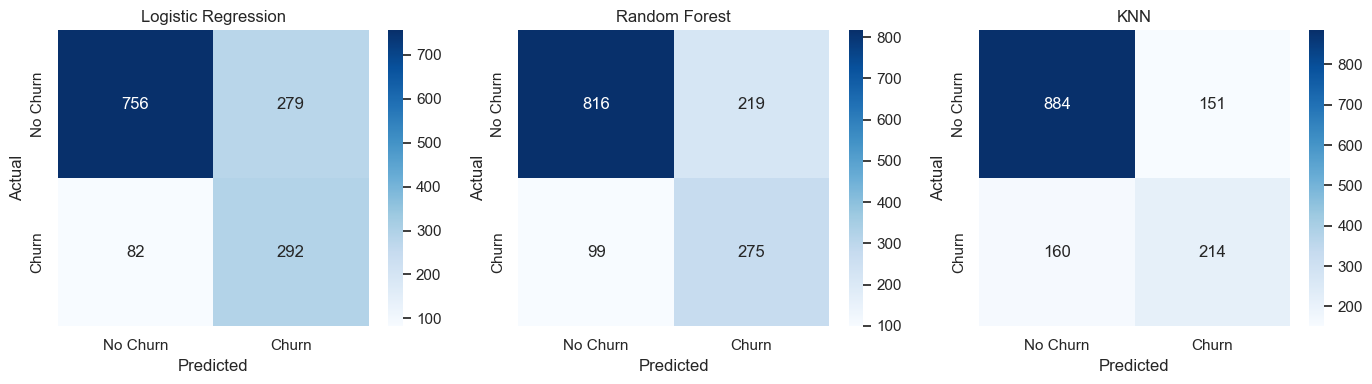

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_confusion_matrix(y_test, y_pred_lr,  'Logistic Regression', axes[0])
plot_confusion_matrix(y_test, y_pred_rf,  'Random Forest',       axes[1])
plot_confusion_matrix(y_test, y_pred_knn, 'KNN',                 axes[2])

plt.tight_layout()
plt.savefig('../outputs/figures/10_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC Curves

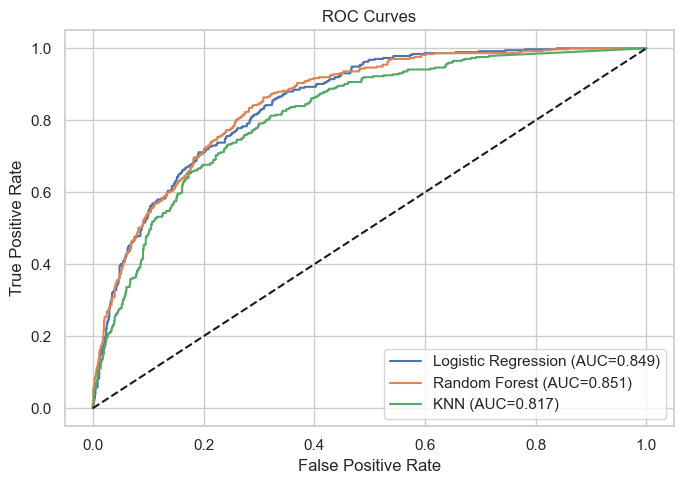

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

models = {'Logistic Regression': lr, 'Random Forest': rf, 'KNN': knn}
plot_roc(models, X_test, y_test, ax)

plt.tight_layout()
plt.savefig('../outputs/figures/11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Comparison

In [12]:
results = {
    'Logistic Regression': metrics_lr,
    'Random Forest': metrics_rf,
    'KNN': metrics_knn
}

comparison = pd.DataFrame(results).T.round(4)
display(comparison)

,Accuracy,Precision,Recall,F1-Score,MCC,ROC-AUC
Logistic Regression,0.7438,0.5114,0.7807,0.6180,0.4598,0.8489
Random Forest,0.7743,0.5567,0.7353,0.6336,0.4846,0.8510
KNN,0.7793,0.5863,0.5722,0.5792,0.4297,0.8166


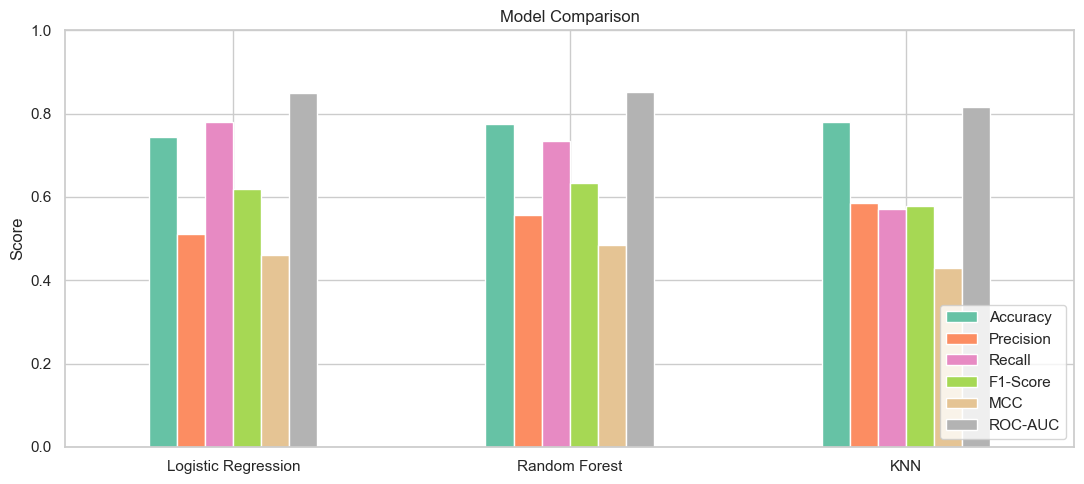

In [13]:
comparison.plot(kind='bar', figsize=(11, 5), rot=0, colormap='Set2')
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Models

In [14]:
import os
os.makedirs('../outputs/models', exist_ok=True)

joblib.dump(lr,  '../outputs/models/logistic_regression.pkl')
joblib.dump(rf,  '../outputs/models/random_forest.pkl')
joblib.dump(knn, '../outputs/models/knn.pkl')

print('Models saved.')

Models saved.
